In [13]:
import numpy as np

def parse_sign_matrix(text):
    """conver + to +1, - to -1"""
    lines = [line.strip() for line in text.strip().splitlines() if line.strip()]
    return np.array([[1 if c == '+' else -1 for c in line] for line in lines], dtype=int)

def normalize_pm_matrix(H):
    """normalize ±1 matrix s.t. first row and first column are all +1"""
    H = H.copy()
    n = len(H)
    for j in range(n):
        if H[0, j] == -1: H[:, j] *= -1
    for i in range(n):
        if H[i, 0] == -1: H[i, :] *= -1
    return H

def reduce_to_01_matrix(text):
    """conver NxN ±1 matrix to (N-1)x(N-1) 0/1 matrix"""
    H = normalize_pm_matrix(parse_sign_matrix(text))
    B = H[1:, 1:]
    A = (1 - B) // 2   # +1→0, -1→1
    return A


text = """
+++++++++----------------
++----+--++++++----------
++----+--------++++++----
----+++------++++------++
------+++++------++----++
--++--+----++------++--++
+-+-+-----+---+---++--+-+
+----+-+-+-+----+---+-+-+
+--+----+---++-+-+----+-+
-+-+-+---+----+--+-+--++-
-+--+--+--+-+--+----+-++-
-++-----+--+-+--+-+---++-
+-+--+----+--+---+--++-+-
+---+---++--+---+--+-+-+-
+--+---+---+--++--+--+-+-
-+-++----+---+----+-++--+
-+---+--+-++---+---+-+--+
-++----+----+-+-++---+--+
--++--+--++----++----++--
--+-+--+-+-+-+-+-+-+-----
--+--+--++--+-++--+-+----
----+++----++----++--++--
---+-+-+--+-++--+-++-----
---++---+-++--+-++--+----
------+++----++----++++--
"""
A = reduce_to_01_matrix(text)
print("0/1 matrix:\n", A)
# det of A
print(abs(np.linalg.det(A)))

formatted = "upper_bound_matrix = [\n    " + ";\n    ".join(
    [" ".join(map(str, row)) for row in A]
) + "\n];"

print(formatted)

0/1 matrix:
 [[0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 0 0 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 0]
 [0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 0]
 [1 0 1 0 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 1]
 [1 1 1 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1]
 [1 1 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 1]
 [1 0 1 0 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1]
 [1 0 0 1 0 0 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 0 0 1]
 [1 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1]
 [1 0 1 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 1 0 1 0]
 [1 1 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0]
 [1 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 0 0 1 0 1 0]
 [1 0 1 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0]
 [1 0 0 0 1 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0]
 [1 1 0 0 0 0 1 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0]
 [0 1 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1 0 0 1 1]
 [0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 1 1 1 1]
 [0 1 0 0 1 0 0 1 

In [14]:
"""the other way to find the second largest determinant:
I thought about finding any possible det between the largest and the largest found in patternboost, 
but it seems it can only do random sampling to find other determinants, not guarantee to find the second largest one.
"""
M_max = A.copy()
det_max = abs(round(np.linalg.det(M_max)))

# flip one element in the matrix and check the determint
# find the largest determinant after single flip
def second_best_single_flip(M, det_max):
    n = M.shape[0]
    det_second_best = 0
    best_matrix = None

    for i in range(n):
        for j in range(n):
            # flip M[i,j]
            M_flipped = M.copy()
            M_flipped[i, j] = 1 - M_flipped[i, j]  # flip 0 to 1 or 1 to 0
            det_flipped = abs(round(np.linalg.det(M_flipped)))

            if det_flipped < det_max and det_flipped > det_second_best:
                det_second_best = det_flipped
                best_matrix = M_flipped

    return best_matrix, det_second_best

M_second_best, det_second_best = second_best_single_flip(M_max, det_max)
print("Second largest determinant found by single flip:", det_second_best)
print("Matrix with second largest determinant:\n", M_second_best)

julia_formatted = "second_largest_matrix = [\n    " + ";\n    ".join(
    [" ".join(map(str, row)) for row in M_second_best]
) + "\n];"

print(julia_formatted)

Second largest determinant found by single flip: 14149085184
Matrix with second largest determinant:
 [[0 0 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 0 0 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 0]
 [0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 0]
 [1 0 1 0 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 1]
 [1 1 1 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1]
 [1 1 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 1]
 [1 0 1 0 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1]
 [1 0 0 1 0 0 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 0 0 1]
 [1 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1]
 [1 0 1 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 1 0 1 0]
 [1 1 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0]
 [1 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 0 0 1 0 1 0]
 [1 0 1 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0]
 [1 0 0 0 1 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0]
 [1 1 0 0 0 0 1 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0]
 [0 1 1 0 0 1 0 0 0 0 1 1 1 1 0

In [16]:
M_max = A.copy()
det_max = abs(round(np.linalg.det(M_max)))

# double flip to find the the largest determinant in these matrices
def max_det_double_flip(M, det_max):
    n = M.shape[0]
    det_best = 0
    best_matrix = None

    for i1 in range(n):
        for j1 in range(n):
            for i2 in range(n):
                for j2 in range(n):
                    if i1 == i2 and j1 == j2:
                        continue  # skip same element flip

                    # flip M[i1,j1] and M[i2,j2]
                    M_flipped = M.copy()
                    M_flipped[i1, j1] = 1 - M_flipped[i1, j1]
                    M_flipped[i2, j2] = 1 - M_flipped[i2, j2]
                    det_flipped = abs(round(np.linalg.det(M_flipped)))

                    if det_flipped < det_max and det_flipped > det_best:
                        det_best = det_flipped
                        best_matrix = M_flipped

    return best_matrix, det_best

M_double_flip_best, det_double_flip_best = max_det_double_flip(M_max, det_max)
print("Largest determinant found by double flip:", det_double_flip_best)
print("Matrix with largest determinant found by double flip:\n", M_double_flip_best)

julia_formatted_double = "double_flip_largest_matrix = [\n    " + ";\n    ".join(
    [" ".join(map(str, row)) for row in M_double_flip_best]
) + "\n];"
print(julia_formatted_double)

Largest determinant found by double flip: 13242092544
Matrix with largest determinant found by double flip:
 [[0 0 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 0 0 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 0]
 [0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 0]
 [1 0 1 0 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 1]
 [1 1 1 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1]
 [1 1 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 1]
 [1 0 1 0 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1]
 [1 0 0 1 0 0 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 0 0 1]
 [1 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1]
 [1 0 1 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 1 0 1 0]
 [1 1 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0]
 [1 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 0 0 1 0 1 0]
 [1 0 1 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0]
 [1 0 0 0 1 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0]
 [1 1 0 0 0 0 1 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0]
 [0 1 1 0 0 1 0 0 0 0 1 

In [ ]:
# Modified version to store matrices for each determinant value
from collections import Counter, defaultdict

N = 17

def decode_matrix(line):
    """decode a line of 0/1 string to a matrix"""
    try: 
        row_strs = line.strip().split(",")

        if len(row_strs) != N:
            return None
        
        matrix = []
        for row in row_strs:
            # validate row
            if len(row) != N:
                return None
            if not all(c in "01" for c in row):
                return None

            matrix.append([int(c) for c in row])

        matrix = np.array(matrix, dtype=int)

        if matrix.shape != (N, N):
            return None  
        return matrix
    
    except Exception:
        return None

def canonical_form(A):
    """return the canonical form of matrix A under row and column permutations"""
    A_sorted_rows = np.array(sorted(A.tolist()))
    A_sorted_cols = np.array(sorted(A_sorted_rows.T.tolist())).T
    return ''.join(map(str, A_sorted_cols.flatten().tolist()))

file_path = "C:/Users/123li/Downloads/Project/gpu_run_output/dim17_run_5/1111/transformer-output-decoded.txt"
with open(file_path, encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

invalid_count = 0
canonical_strings = {}
det_to_matrices = defaultdict(list)  # Store matrices for each determinant

for line in lines:
    A = decode_matrix(line)
    if A is None:
        invalid_count += 1
        continue
    
    can_str = canonical_form(A)
    if can_str not in canonical_strings:  # ensure no repeats
        det = round(abs(np.linalg.det(A))) 
        canonical_strings[can_str] = det
        # Store the matrix for this determinant
        det_to_matrices[det].append(A.copy())

print(f"Total matrices: {len(lines)}")
print(f"Unique (up to permutation): {len(canonical_strings)}")
print(f"Duplicate rate: {(1 - len(canonical_strings)/len(lines))*100:.2f}%")
print(f"Invalid matrices: {invalid_count}")
print("\n")

# Determinant distribution with matrices
det_counts = Counter(canonical_strings.values())
print("Det distribution with sample matrices:")
print("=" * 50)

sort_dets = sorted(det_counts.items(), reverse=True)
for rank, (det, count) in enumerate(sort_dets, start=1):
    print(f"\nDeterminant: {det}, Count: {count}")
    
    # Print up to 2 example matrices for this determinant
    if rank <= 5:
        matrices_for_det = det_to_matrices[det]
        num_to_show = min(2, len(matrices_for_det))
        
        for i in range(num_to_show):
            print(f"Example matrix {i+1}:")
            print(matrices_for_det[i])
            if i < num_to_show - 1:
                print()
        
        if len(matrices_for_det) > num_to_show:
            print(f"... and {len(matrices_for_det) - num_to_show} more matrices with det = {det}")
    print("=" * 50)

In [2]:
import networkx as nx
import numpy as np

def equivalent_via_graph(A, B):
    A = np.array(A)
    B = np.array(B)
    n, m = A.shape
    if B.shape != (n, m):
        return False

    G1 = nx.Graph()
    G2 = nx.Graph()

    # Add bipartite nodes: rows and columns
    G1.add_nodes_from(range(n), bipartite=0)
    G1.add_nodes_from(range(n, n+m), bipartite=1)
    
    G2.add_nodes_from(range(n), bipartite=0)
    G2.add_nodes_from(range(n, n+m), bipartite=1)

    # Add edges for 1 entries
    for i in range(n):
        for j in range(m):
            if A[i, j]:
                G1.add_edge(i, n + j)
            if B[i, j]:
                G2.add_edge(i, n + j)

    # Check isomorphism
    return nx.is_isomorphic(G1, G2)

def decode_matrix(line):
    """decode a line of 0/1 string to a matrix"""
    try: 
        row_strs = line.strip().split(",")

        if len(row_strs) != N:
            return None
        
        matrix = []
        for row in row_strs:
            # validate row
            if len(row) != N:
                return None
            if not all(c in "01" for c in row):
                return None

            matrix.append([int(c) for c in row])

        matrix = np.array(matrix, dtype=int)

        if matrix.shape != (N, N):
            return None  
        return matrix
    
    except Exception:
        return None


In [ ]:
import numpy as np
from collections import defaultdict, Counter

matrices = []
N = 19

file_path = "C:/Users/123li/Downloads/Project/gpu_run_output/dim19_run_2/1111/transformer-output-decoded.txt"
with open(file_path, encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

for line in lines:
    A = decode_matrix(line)
    if A is not None and A.shape == (N, N):
        matrices.append(A)

if matrices:
    print("Total matrices loaded for equivalence check =", len(matrices))

# step 1: group by determinant value
det_groups = defaultdict(list)
det_values = []
for A in matrices:
    det = round(abs(np.linalg.det(A)))
    det_groups[det].append(A)
    det_values.append(det)

det_counts = Counter(det_values)

# step 2: only focus on the top 5 determinant values and its count
top1 = sorted(det_counts.items(), key=lambda x: x[0], reverse=True)[:1]

print("Top 5 determinant groups:\n")
for i, (det, count) in enumerate(top5, start=1):
    print(f"{i}. det = {det}, count = {count}")

# adding a step here, create a function called fingerprint, to generate a unique fingerprint for each matrix
# increase efficiency of isomorphism checking
def fingerprint(A):
    """generate a fingerprint for matrix A based on row and column sums"""
    row_sums = tuple(sorted(np.sum(A, axis=1).tolist())) 
    col_sums = tuple(sorted(np.sum(A, axis=0).tolist()))

    eig = np.linalg.eigvals(A).round(5)
    eig = sorted((float(ev.real), float(ev.imag)) for ev in eig)
    eigenvalues = tuple(eig)
    return (row_sums, col_sums, eigenvalues)


# step 3: within these top 5 groups, use graph isomorphism to find unique matrices
def unique_in_group(matrices):
    # input: list of matrices in the same determinant group
    # output: list of unique matrices under row/column permutations
    # based on equivalent_via_graph function
    hash_table = {}
    unique_matrices = []

    for A in matrices:
        fp = fingerprint(A)
        is_new = True

        if fp not in hash_table:
            hash_table[fp] = [A]
            unique_matrices.append(A)
            continue

        for B in hash_table[fp]:
            if equivalent_via_graph(A, B):
                is_new = False
                break

        if is_new:
            unique_matrices.append(A)
            hash_table[fp].append(A)

    return unique_matrices

# step 4: get the number of unique matrices in each top 1 determinant group
# and print out some sample matrices
for det, count in top1:
    group_matrices = det_groups[det]

    print(f"\nDeterminant: {det}, Total Count: {count}")

    # if there is only one matrix in the group, no need to check equivalence
    if count == 1:
        print("Only one matrix in this group.")
        print("unique matrix:")
        print(group_matrices[0])
        continue

    unique_list = unique_in_group(group_matrices)
    unique_count = len(unique_list)
    print(f"Unique matrices under row/column permutations: {unique_count}")

    # print up to 2 sample unique matrices
    num_to_show = min(2, unique_count)
    for i in range(num_to_show):
        print(f"Sample unique matrix {i+1}:")
        print(unique_list[i])
        if i < num_to_show - 1:
            print()

In [4]:
import numpy as np
from collections import defaultdict, Counter

matrices = []
N = 14

file_path = "C:/Users/123li/Downloads/Project/gpu_run_output/dim14_run_3/1111/transformer-output-decoded.txt"
with open(file_path, encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

for line in lines:
    A = decode_matrix(line)
    if A is not None and A.shape == (N, N):
        matrices.append(A)

if matrices:
    print("Total matrices loaded for equivalence check =", len(matrices))

# step 1: group by determinant value
det_groups = defaultdict(list)
det_values = []
for A in matrices:
    det = round(abs(np.linalg.det(A)))
    det_groups[det].append(A)
    det_values.append(det)

det_counts = Counter(det_values)

# step 2: only focus on the top 5 determinant values and its count
top5 = sorted(det_counts.items(), key=lambda x: x[0], reverse=True)[:5]

print("Top 5 determinant groups:\n")
for i, (det, count) in enumerate(top5, start=1):
    print(f"{i}. det = {det}, count = {count}")

# step 3: within these top 5 groups, use graph isomorphism to find unique matrices
def unique_in_group(matrices):
    # input: list of matrices in the same determinant group
    # output: list of unique matrices under row/column permutations
    # based on equivalent_via_graph function
    unique_matrices = []

    for A in matrices:
        is_new = True

        for B in unique_matrices:
            if equivalent_via_graph(A, B):
                is_new = False
                break

        if is_new:
            unique_matrices.append(A)

    return unique_matrices

# step 4: get the number of unique matrices in each top 5 determinant group
# and print out some sample matrices
for det, count in top5:
    group_matrices = det_groups[det]

    print(f"\nDeterminant: {det}, Total Count: {count}")

    # if there is only one matrix in the group, no need to check equivalence
    if count == 1:
        print("Only one matrix in this group.")
        print("unique matrix:")
        print(group_matrices[0])
        continue

    unique_list = unique_in_group(group_matrices)
    unique_count = len(unique_list)
    print(f"Unique matrices under row/column permutations: {unique_count}")

    # print up to 2 sample unique matrices
    num_to_show = min(2, unique_count)
    for i in range(num_to_show):
        print(f"Sample unique matrix {i+1}:")
        print(unique_list[i])
        if i < num_to_show - 1:
            print()

Total matrices loaded for equivalence check = 40629
Top 5 determinant groups:

1. det = 25515, count = 952
2. det = 24435, count = 12759
3. det = 24300, count = 3892
4. det = 24099, count = 15903
5. det = 24003, count = 4331

Determinant: 25515, Total Count: 952
Unique matrices under row/column permutations: 2
Sample unique matrix 1:
[[0 1 1 1 1 0 1 0 1 1 0 0 1 0]
 [0 0 0 1 0 1 1 0 0 1 1 1 1 1]
 [0 0 1 1 1 0 0 1 1 1 1 1 0 0]
 [0 0 1 0 1 1 0 0 1 0 1 0 1 1]
 [1 0 1 0 0 0 1 1 0 0 0 1 1 1]
 [0 1 1 0 0 1 0 1 0 1 0 0 0 1]
 [1 0 0 1 0 1 1 1 1 0 0 0 0 1]
 [1 1 1 1 0 0 0 0 0 0 1 0 0 1]
 [1 1 0 0 1 0 0 0 1 1 0 1 0 1]
 [1 0 1 0 1 1 1 0 0 1 1 0 0 0]
 [0 1 1 0 0 1 1 0 1 0 1 1 0 0]
 [1 1 0 0 0 0 0 1 1 1 1 0 1 0]
 [0 1 0 0 1 0 1 1 0 0 1 0 0 1]
 [1 1 0 1 1 1 0 1 0 0 0 1 1 0]]

Sample unique matrix 2:
[[1 0 1 0 1 0 1 0 1 0 1 1 1 0]
 [1 1 1 1 1 0 1 1 1 1 0 0 0 0]
 [0 0 0 1 0 0 1 1 0 1 1 1 1 0]
 [1 1 0 1 0 0 1 0 0 0 0 1 1 1]
 [0 0 0 0 1 1 1 1 1 0 0 1 0 1]
 [0 1 1 0 0 0 1 1 1 0 1 0 1 1]
 [0 1 1 1 0 1 0 0 

KeyboardInterrupt: 

Epoch 1: max det = 3411968, top5 = [3411968, 3031476, 3008400, 2967040, 2896896], unique_counts = [1, 1, 1, 1, 1]
Epoch 2: max det = 3411968, top5 = [3411968, 3031476, 3008400, 2967040, 2896896], unique_counts = [1, 1, 1, 1, 1]
Epoch 3: max det = 3411968, top5 = [3411968, 3031476, 3023296, 3008400, 2967040], unique_counts = [1, 1, 1, 1, 1]
Epoch 4: max det = 3411968, top5 = [3411968, 3031476, 3023296, 3008400, 2993192], unique_counts = [1, 1, 1, 1, 1]
Epoch 5: max det = 3411968, top5 = [3411968, 3031476, 3023296, 3008400, 2993192], unique_counts = [1, 1, 1, 1, 1]
Epoch 6: max det = 3411968, top5 = [3411968, 3031476, 3023296, 3008400, 2993192], unique_counts = [1, 1, 1, 1, 1]
Epoch 7: max det = 3411968, top5 = [3411968, 3031476, 3023296, 3008400, 2993192], unique_counts = [1, 1, 1, 1, 1]
Epoch 8: max det = 3411968, top5 = [3411968, 3031476, 3024424, 3023296, 3008400], unique_counts = [1, 1, 1, 1, 1]
Epoch 9: max det = 3411968, top5 = [3411968, 3031476, 3024424, 3023296, 3008400], unique

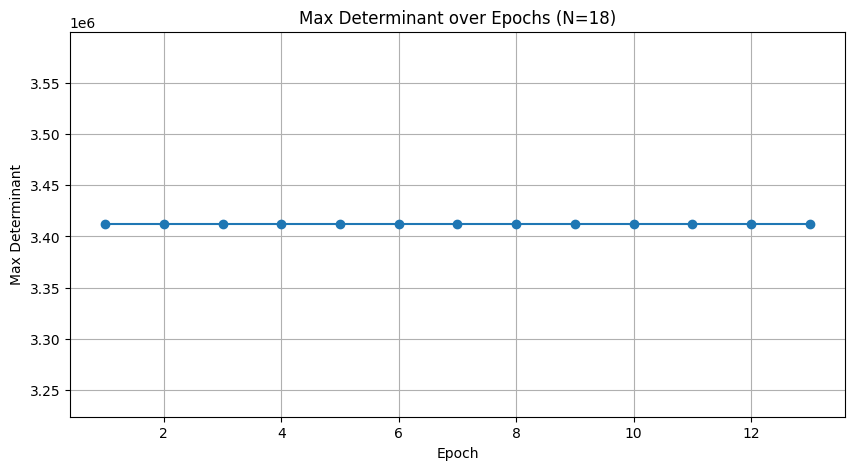

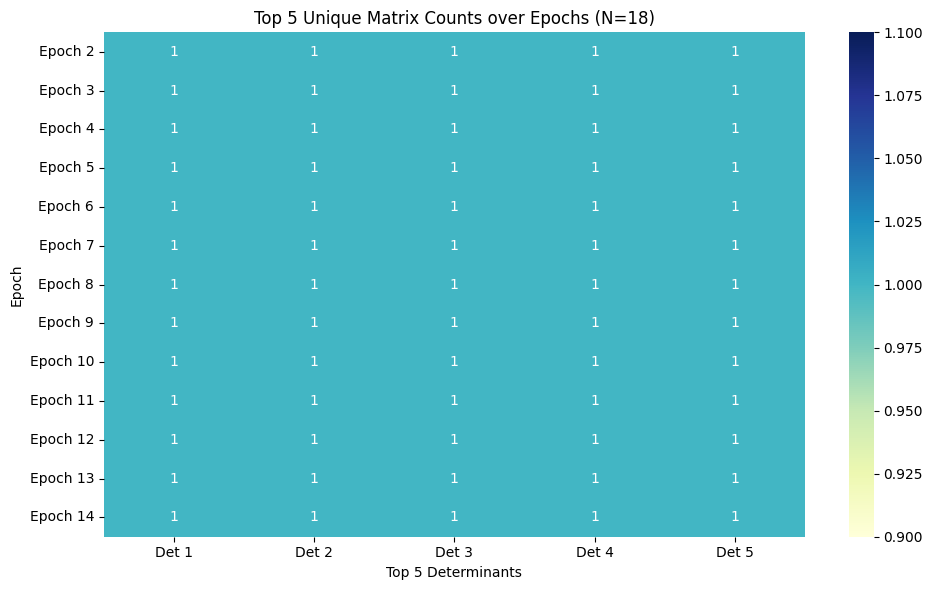

In [5]:
# visulize the distribution of determinants
import matplotlib.pyplot as plt
import os
import seaborn as sns

def process_search_output_files(file_paths, N):
    """
    process multiple search output files to extract determinant distribution
    """
    if not os.path.exists(file_paths):
        return None
    
    matrices = []
    with open(file_paths, encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:
        A = decode_matrix(line)
        if A is not None and A.shape == (N, N):
            matrices.append(A)

    if not matrices:
        return None
    
    # grouping by determinant value
    det_groups = defaultdict(list)
    for A in matrices:
        det = round(abs(np.linalg.det(A)))
        det_groups[det].append(A)   

    # top 5 determinant groups
    det_counts = Counter({det: len(mats) for det, mats in det_groups.items()})
    top5 = sorted(det_counts.items(), key=lambda x: x[0], reverse=True)[:5]
    top5_dets = [det for det, count in top5]

    # compute unique counts
    top5_unique_counts = []
    for det, count in top5:
        group = det_groups[det]
        unique_count = len(unique_in_group(group))
        top5_unique_counts.append(unique_count)

    max_det = top5_dets[0]

    return max_det, top5_dets, top5_unique_counts


folder_path = "C:/Users/123li/Downloads/Project/gpu_run_output/dim18_run_1/1111/"
N = 18

epoch = 1
max_dets = []
heatmap_rows = []
heatmap_labels = []  # determinant labels per epoch

while True:
    file_path = os.path.join(folder_path, f"search_output_{epoch}.txt")
    result = process_search_output_files(file_path, N)

    if result is None:
        break  # no more files

    max_det, top5_dets, top5_unique = result

    max_dets.append(max_det)
    heatmap_rows.append(top5_unique)
    heatmap_labels.append(top5_dets)

    print(f"Epoch {epoch}: max det = {max_det}, top5 = {top5_dets}, unique_counts = {top5_unique}")
    epoch += 1

num_epochs = len(max_dets)
print(f"\nTotal epochs found = {num_epochs}")


# plot 1: max determinant over epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), max_dets, marker='o')
plt.title(f'Max Determinant over Epochs (N={N})')
plt.xlabel('Epoch')
plt.ylabel('Max Determinant')
plt.grid(True)
plt.tight_layout
plt.show()

# plot 2: heatmap of top 5 unique counts over epochs
heatmap_data = np.array(heatmap_rows)
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=[f"Det {i+1}" for i in range(5)],
            yticklabels=[f"Epoch {i+1}" for i in range(1, num_epochs + 1)])

plt.title(f'Top 5 Unique Matrix Counts over Epochs (N={N})')
plt.xlabel('Top 5 Determinants')
plt.ylabel('Epoch')
plt.tight_layout()
plt.show()

In [ ]:
# brute force pairwise comparison
unique_groups = []
matrices = [...]

file_path = "C:/Users/123li/Downloads/Project/gpu_run_output/dim16_run_9/1111/transformer-output-decoded.txt"
with open(file_path, encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

for line in lines:
    A = decode_matrix(line)
    if A is not None:
        matrices.append(A)

if matrices:
    print("Total matrices loaded for equivalence check =", len(matrices))

for i, A in enumerate(matrices):
    placed = False
    for group in unique_groups:
        B = group[0]               # compare with representative
        if equivalent_via_graph(A, B):
            group.append(A)
            placed = True
            break
    if not placed:
        unique_groups.append([A])  # new class

print("Total unique groups =", len(unique_groups))